**Alishba Bacha**

**2022088-AI**

**AI-351 Lab 05**

**Task1**

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

df = pd.read_csv('insurance-dataset.csv', encoding = 'latin-1')
df.head()

,Age,Premium
0,18,10000
1,22,15000
2,23,18000
3,26,21000
4,28,24000


In [70]:
X = df[['Age']]
Y = df[['Premium']]

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
linear_reg = LinearRegression()
linear_reg.fit(X_train,Y_train)
Y_pred_linear = linear_reg.predict(X_test)

In [74]:
mse_linear = mean_squared_error(Y_test, Y_pred_linear)
r2_linear = r2_score(Y_test, Y_pred_linear)

print("MSE:", mse_linear)
print("R-squared:", r2_linear)

MSE: 9803085.317862792
R-squared: -0.5684936508580467


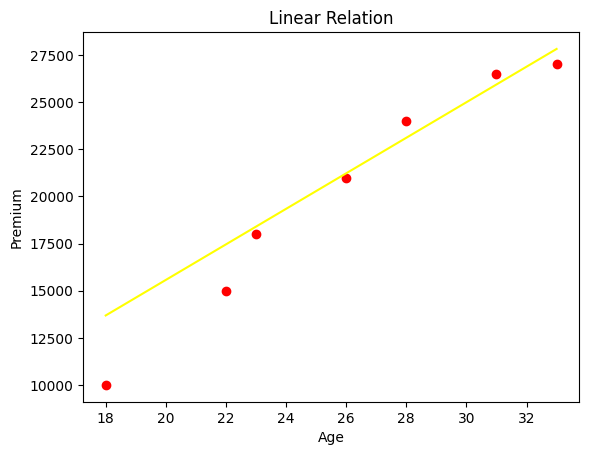

In [75]:
plt.scatter(X,Y, color='red')
plt.plot(X, linear_reg.predict(X),color='Yellow')
plt.title("Linear Relation")
plt.xlabel('Age')
plt.ylabel('Premium')
plt.show()

In [77]:
poly_reg = PolynomialFeatures(degree=3)
X_poly_train = poly_reg.fit_transform(X_train)
X_poly_test = poly_reg.transform(X_test)

In [78]:
linear_reg2 = LinearRegression()
linear_reg2.fit(X_poly_train, Y_train)
Y_pred_poly = linear_reg2.predict(X_poly_test)

In [79]:
mse_poly = mean_squared_error(Y_test, Y_pred_poly)
r2_poly = r2_score(Y_test, Y_pred_poly)
print("Polynomial of degree=3 MSE:", mse_poly)
print("Polynomial of degree=3 R-squared:", r2_poly)

Polynomial of degree=3 MSE: 52831264.688978806
Polynomial of degree=3 R-squared: -7.453002350236609


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


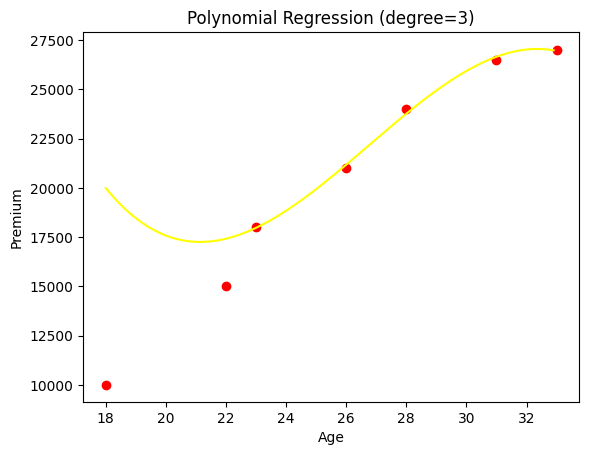

In [81]:
X_age = X['Age'].values
X_grid = np.arange(min(X_age), max(X_age), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, Y, color='red')
plt.plot(X_grid, linear_reg2.predict(poly_reg.transform(X_grid)), color='yellow')
plt.title("Polynomial Regression (degree=3)")
plt.xlabel('Age')
plt.ylabel('Premium')
plt.show()

Polynomial of degree=2 MSE: 1001627.2039464996
Polynomial of degree=2 R-squared: 0.8397396473685601


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


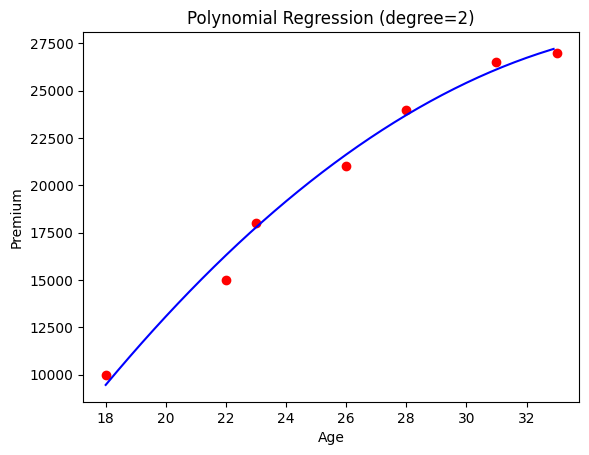

Polynomial of degree=4 MSE: 622152183.9265225
Polynomial of degree=4 R-squared: -98.54434942824359


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


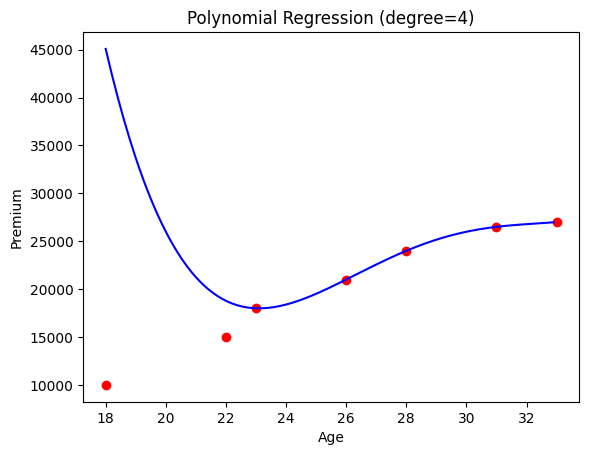

Polynomial of degree=5 MSE: 379720024.18263924
Polynomial of degree=5 R-squared: -59.75520386922228


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


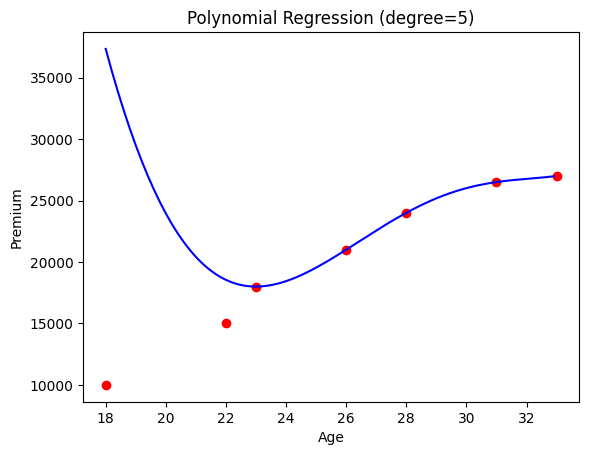

In [84]:
for degree in [2,4,5]:
    poly_reg = PolynomialFeatures(degree=degree)
    X_poly_train = poly_reg.fit_transform(X_train)
    X_poly_test = poly_reg.transform(X_test)

    linear_reg2 = LinearRegression()
    linear_reg2.fit(X_poly_train, Y_train)

    Y_pred_poly = linear_reg2.predict(X_poly_test)

    mse_poly = mean_squared_error(Y_test, Y_pred_poly)
    r2_poly = r2_score(Y_test, Y_pred_poly)

    print(f"Polynomial of degree={degree} MSE:", mse_poly)
    print(f"Polynomial of degree={degree} R-squared:", r2_poly)

    plt.scatter(X, Y, color='red')
    plt.plot(X_grid, linear_reg2.predict(poly_reg.transform(X_grid)), color='blue')
    plt.title(f"Polynomial Regression (degree={degree})")
    plt.xlabel('Age')
    plt.ylabel('Premium')
    plt.show()

**Underfitting:**

In case of simple linear regression the model face underfitting as model does not do well on both training and testing dataset because the model is so simple that it cannot capture the complexity of dataset.

**Overfitting:**

In case of more higher model the data overfits and perform well on training data but not testing data because it learn the noise in train data.

**Task2**

In [85]:
df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [87]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


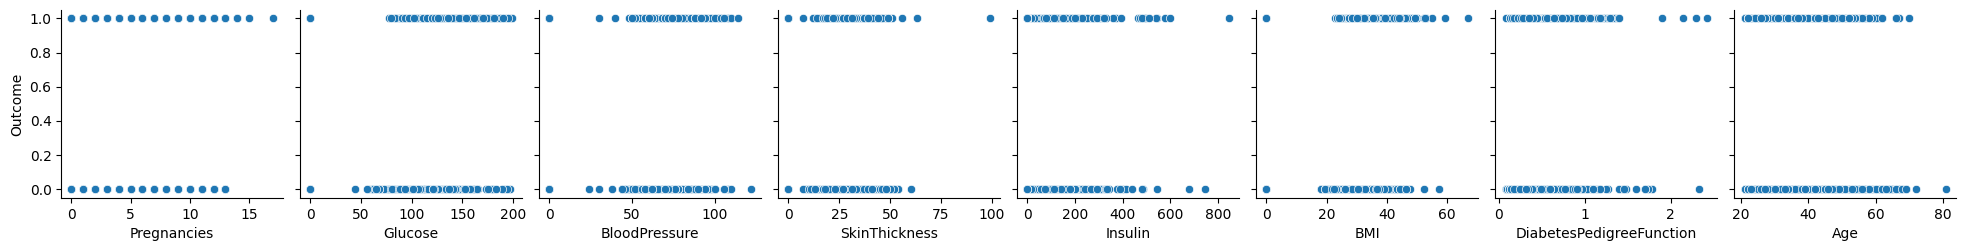

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, y_vars='Outcome', x_vars=df.columns[:-1])
plt.show()


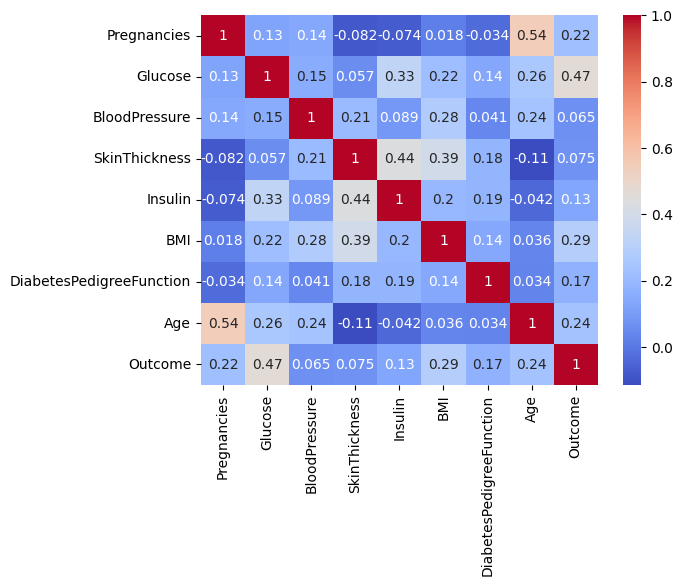

In [90]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [91]:
selected_features = ['Pregnancies', 'BloodPressure', 'Glucose']
X = df[selected_features]
y = df['Outcome']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


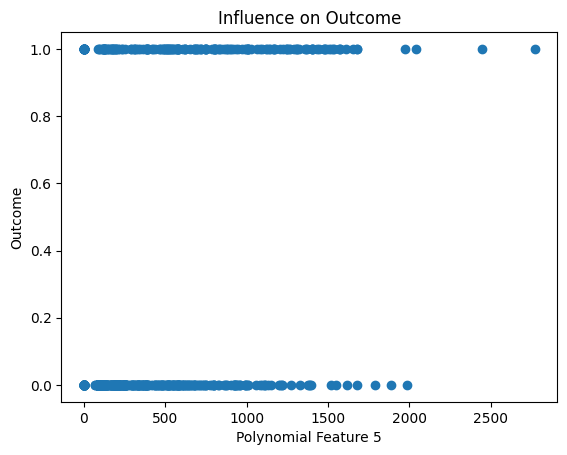

In [93]:
feature_index = 5
plt.scatter(X_train_poly[:, feature_index], y_train)
plt.xlabel(f'Polynomial Feature {feature_index}')
plt.ylabel('Outcome')
plt.title('Influence on Outcome')
plt.show()


In [94]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

In [95]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Polynomial Degree: {degree}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')


Polynomial Degree: 3
Mean Squared Error: 0.17
R-squared: 0.26


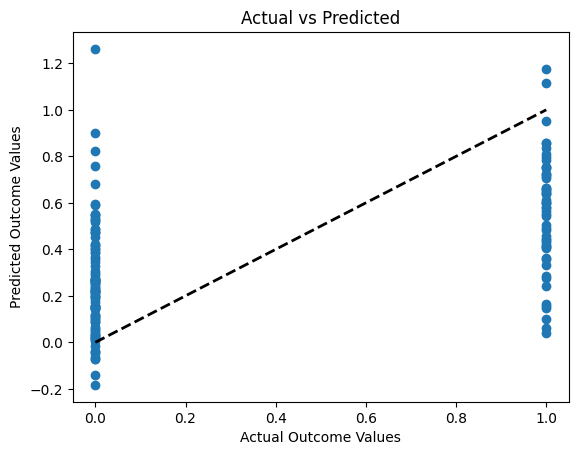

In [96]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Outcome Values')
plt.ylabel('Predicted Outcome Values')
plt.title('Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()


Polynomial Degree: 1
Mean Squared Error: 0.16
R-squared: 0.30



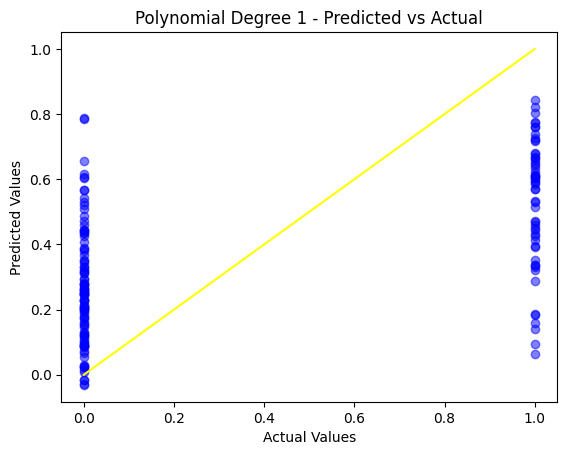

Polynomial Degree: 2
Mean Squared Error: 0.16
R-squared: 0.31



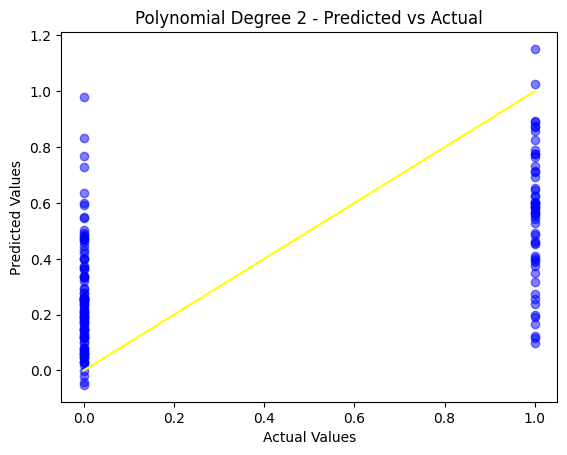

Polynomial Degree: 3
Mean Squared Error: 0.17
R-squared: 0.26



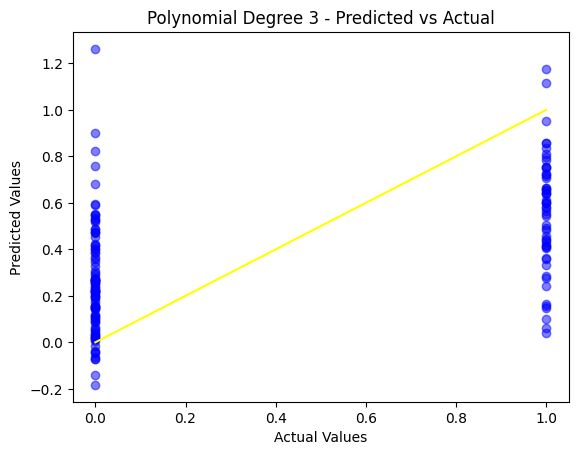

Polynomial Degree: 4
Mean Squared Error: 0.18
R-squared: 0.23



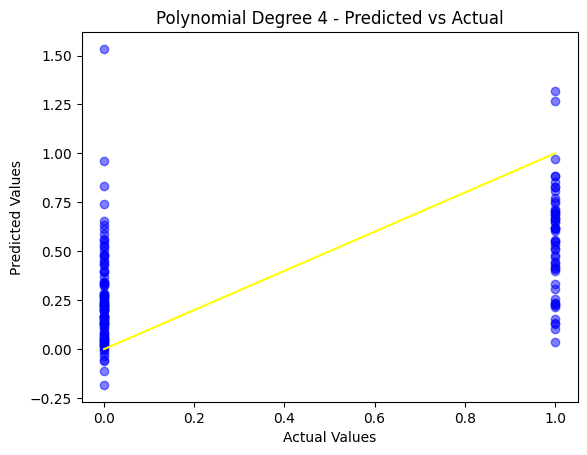

In [100]:
degrees = [1, 2, 3, 4]
mse_list = []
r2_list = []

for degree in [1,2,3,4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_list.append(mse)
    r2_list.append(r2)

    print(f'Polynomial Degree: {degree}')
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R-squared: {r2:.2f}\n')

    plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='Yellow')
    plt.title(f"Polynomial Degree {degree} - Predicted vs Actual")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.show()


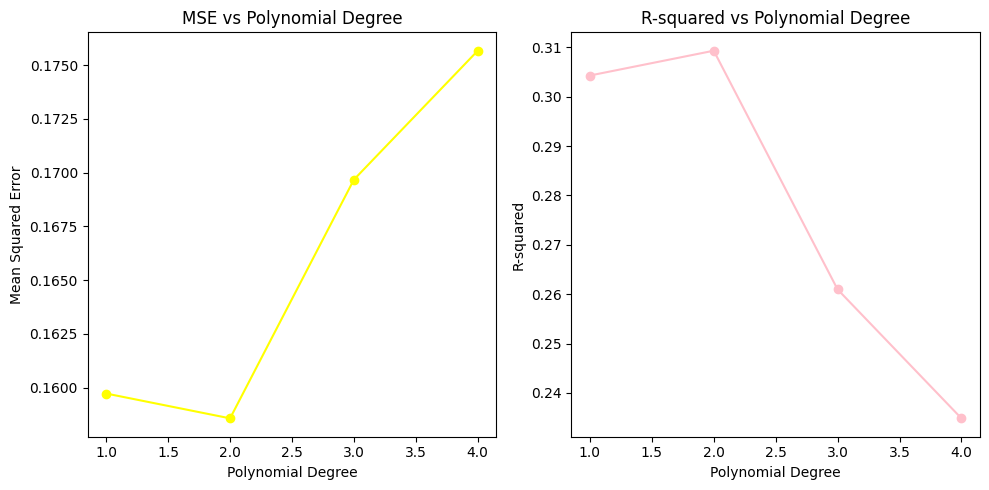

In [99]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(degrees, mse_list, marker='o', color = 'yellow')
plt.title('MSE vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')

plt.subplot(1, 2, 2)
plt.plot(degrees, r2_list, marker='o', color='pink')
plt.title('R-squared vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared')

plt.tight_layout()
plt.show()


As we can see in the visuals as degree increases the model converge for overfitting